<a href="https://colab.research.google.com/github/Kevinlo937/cord-cutting-predicated/blob/main/topMSO_add_Vars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import glob
import os

# 設定目錄路徑
directory_path = '/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/過濾資料/帳單/'

# 取得所有檔名以 '帳單_' 開頭的 .csv 檔案的路徑
all_files = glob.glob(os.path.join(directory_path, "帳單_*.csv"))

# 建立一個空的 list 來存放所有 DataFrame
all_dataframes = []

# 迭代所有檔案路徑，讀取 CSV 並加入 list
for filename in all_files:
    df = pd.read_csv(filename, sep='^')
    all_dataframes.append(df)

# 使用 pd.concat 合併所有 DataFrame
ds_bill = pd.concat(all_dataframes, ignore_index=True)

topMSO_add_Vars.ipynb

目的：主要增加 平均繳款延遲日數、最常見交款方式 兩項帳務特徵，然後做新一輪模型訓練

1.取得2022~2024帳單資料，清洗掉0元帳單及目標日期區間外的帳單資料後，輸出bill_22_24_filtered.csv，包含下欄位資訊
客編	相關編號	帳單起日	帳單迄日	金額	銷帳日期	繳別	繳費方式

2.與相同2022~2024 區間已數值化派工資料集 ds_numService.csv 資料集合併，輸出ds_numService_with_billing.csv

In [ ]:
ds_bill.to_csv('bill_22_24.csv', index=False, sep='^')

In [ ]:
ds_bill.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
0,674831,1272367,1970/01/01 08:00:00,1970/01/01 08:00:00,0,14-2月 -22,1,CVS臨櫃代收(7-11)
1,549309,1295146,1970/01/01 08:00:00,1970/01/01 08:00:00,0,14-2月 -22,1,CVS臨櫃代收(7-11)
2,711264,785596,2005/04/17 00:00:00,2005/06/14 00:00:00,1342,23-2月 -22,1,CVS臨櫃代收(7-11)
3,712384,786716,2009/05/01 00:00:00,2009/06/11 00:00:00,820,10-2月 -22,1,CVS臨櫃代收(7-11)
4,702883,777193,2011/09/01 00:00:00,2011/09/30 00:00:00,0,25-2月 -22,1,CVS臨櫃代收(7-11)


In [ ]:
ds_bill.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12261132 entries, 0 to 12261131
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 748.4+ MB


In [ ]:
ds_bill_filtered = ds_bill[ds_bill['金額'] != 0].copy()  # 建立副本


In [ ]:
ds_bill_filtered.loc[:, '帳單起日'] = pd.to_datetime(ds_bill_filtered['帳單起日'], format='%Y/%m/%d %H:%M:%S', errors='coerce')

In [ ]:
ds_bill_filtered.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
2,711264,785596,2005-04-17 00:00:00,2005/06/14 00:00:00,1342,23-2月 -22,1,CVS臨櫃代收(7-11)
3,712384,786716,2009-05-01 00:00:00,2009/06/11 00:00:00,820,10-2月 -22,1,CVS臨櫃代收(7-11)
6,357531,939921,2012-04-11 00:00:00,2012/05/10 00:00:00,600,08-2月 -22,6,CVS臨櫃代收(7-11)
9,917372,1160943,2014-04-09 00:00:00,2014/05/12 00:00:00,453,08-2月 -22,1,CVS臨櫃代收(7-11)
10,848809,923456,2014-06-01 00:00:00,2014/07/09 00:00:00,760,24-2月 -22,1,CVS臨櫃代收(7-11)


In [ ]:
ds_bill_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5110734 entries, 2 to 12261131
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 350.9+ MB


In [ ]:
# 篩選帳單起日在 2022 年至 2024 年之間的資料
ds_bill_filtered = ds_bill_filtered[
    (ds_bill_filtered['帳單起日'] >= pd.Timestamp('2022-01-01')) &
    (ds_bill_filtered['帳單起日'] <= pd.Timestamp('2024-12-31'))
]

In [ ]:
ds_bill_filtered.head(50)

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式
94,712195,2261495,2022-02-10 00:00:00,2023/02/09 00:00:00,900,10-2月 -22,12,CVS臨櫃代收(7-11)
227,523519,1133492,2022-01-29 00:00:00,2022/07/31 00:00:00,120,08-2月 -22,6,簡訊帳單臨櫃代收(7-11)
237,763995,1942146,2022-01-29 00:00:00,2022/07/31 00:00:00,120,08-2月 -22,6,簡訊帳單臨櫃代收(7-11)
652,896140,2235068,2022-02-14 00:00:00,2022/08/13 00:00:00,600,14-2月 -22,6,CVS臨櫃代收(7-11)
762,595177,1908862,2022-01-29 00:00:00,2022/04/28 00:00:00,300,08-2月 -22,3,CVS臨櫃代收(7-11)
838,734957,2252284,2022-02-09 00:00:00,2022/08/08 00:00:00,600,09-2月 -22,6,CVS臨櫃代收(7-11)
2191,791111,1936741,2022-02-12 00:00:00,2022/08/11 00:00:00,120,14-2月 -22,6,簡訊帳單臨櫃代收(7-11)
2401,779470,1006757,2022-02-19 00:00:00,2022/08/18 00:00:00,120,22-2月 -22,6,簡訊帳單臨櫃代收(7-11)
2768,107459,2401915,2022-02-21 00:00:00,2022/08/20 00:00:00,600,21-2月 -22,6,簡訊帳單臨櫃代收(7-11)
2774,314511,2406434,2022-02-06 00:00:00,2022/08/05 00:00:00,600,06-2月 -22,6,CVS臨櫃代收(7-11)


In [ ]:
ds_bill_filtered.to_csv('bill_22_24_filtered.csv', index=False, sep='^')

In [ ]:
# 篩選 2024 年 Q4 的資料
sample_data = ds_bill_filtered[
    (ds_bill_filtered['帳單起日'] >= pd.Timestamp('2024-10-01')) &
    (ds_bill_filtered['帳單起日'] <= pd.Timestamp('2024-12-31'))
]

In [ ]:
sample_data.to_csv('bill_sample_data.csv', index=False, sep='^')

In [ ]:
import pandas as pd
# 載入資料
ds = pd.read_csv('ds_numService.csv',sep='^')

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47879 entries, 0 to 47878
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   客編       47879 non-null  int64  
 1   相關編號     47879 non-null  int64  
 2   30天內     47879 non-null  int64  
 3   60天內     47879 non-null  int64  
 4   90天內     47879 non-null  int64  
 5   90天以上    47879 non-null  int64  
 6   平均等待天數   47879 non-null  float64
 7   繳別       47879 non-null  int64  
 8   使用狀態_數值  47879 non-null  int64  
 9   產品名稱_數值  47879 non-null  int64  
dtypes: float64(1), int64(9)
memory usage: 3.7 MB


In [ ]:
ds = pd.read_csv('/content/bill_22_24_filtered.csv',sep='^')

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1785869 entries, 0 to 1785868
Data columns (total 8 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   客編      int64 
 1   相關編號    int64 
 2   帳單起日    object
 3   帳單迄日    object
 4   金額      int64 
 5   銷帳日期    object
 6   繳別      int64 
 7   繳費方式    object
dtypes: int64(4), object(4)
memory usage: 109.0+ MB


In [ ]:
import pandas as pd
# 載入資料
ds = pd.read_csv('/content/ds_numService_with_billing.csv',sep=',')

In [ ]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47310 entries, 0 to 47309
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   客編        47310 non-null  int64  
 1   相關編號      47310 non-null  int64  
 2   30天內      47310 non-null  int64  
 3   60天內      47310 non-null  int64  
 4   90天內      47310 non-null  int64  
 5   90天以上     47310 non-null  int64  
 6   平均等待天數    47310 non-null  float64
 7   繳別        47310 non-null  int64  
 8   使用狀態_數值   47310 non-null  int64  
 9   產品名稱_數值   47310 non-null  int64  
 10  平均繳款延遲日數  47310 non-null  float64
 11  最常見繳費方式   47310 non-null  object 
dtypes: float64(2), int64(9), object(1)
memory usage: 4.3+ MB


In [ ]:
import pandas as pd

# 載入資料
ds = pd.read_csv('ds_numService.csv',sep='^')
bill = ds_bill_filtered.copy()  # 建立副本

# 清洗欄位名稱
ds.columns = ds.columns.str.strip()
bill.columns = bill.columns.str.strip()

# 👉 將 '銷帳日期' 中中文月份轉為英文縮寫（供 datetime 解析）
month_map = {
    '1月': 'Jan', '2月': 'Feb', '3月': 'Mar', '4月': 'Apr',
    '5月': 'May', '6月': 'Jun', '7月': 'Jul', '8月': 'Aug',
    '9月': 'Sep', '10月': 'Oct', '11月': 'Nov', '12月': 'Dec'
}

# 替換中文月份
for zh, en in month_map.items():
    bill['銷帳日期'] = bill['銷帳日期'].str.replace(zh, en, regex=False)

# 轉換為 datetime 格式
bill['銷帳日期'] = pd.to_datetime(bill['銷帳日期'], format='%d-%b -%y', errors='coerce')

# 解析 '帳單迄日'
bill['帳單起日'] = pd.to_datetime(bill['帳單起日'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 計算延遲日數
bill['繳款延遲日數'] = (bill['銷帳日期'] - bill['帳單起日']).dt.days

# 移除無效記錄以計算平均
valid_bills = bill.dropna(subset=['繳款延遲日數'])
avg_global = round(valid_bills['繳款延遲日數'].mean(), 2)

# 平均延遲日數
delay_avg = bill.groupby('客編')['繳款延遲日數'].mean().reset_index()
delay_avg.columns = ['客編', '平均繳款延遲日數']

# 將全體平均補進 NaN 的客戶
all_customers = bill[['客編']].drop_duplicates()
delay_filled = pd.merge(all_customers, delay_avg, on='客編', how='left')
delay_filled['平均繳款延遲日數'] = delay_filled['平均繳款延遲日數'].fillna(avg_global)

# 最常見繳費方式
payment_mode = bill.groupby('客編')['繳費方式'] \
                   .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else '未知') \
                   .reset_index()
payment_mode.columns = ['客編', '最常見繳費方式']

# 合併帳單特徵
# bill_features = pd.merge(delay_avg, payment_mode, on='客編', how='outer')
bill_features = pd.merge(delay_filled, payment_mode, on='客編', how='left')

# 合併至主訓練集
merged_df = pd.merge(ds, bill_features, on='客編', how='left')

# 儲存
merged_df.to_csv('ds_numService_with_billing.csv', index=False)
print("✅ 成功轉換並合併，已輸出為 ds_numService_with_billing.csv")

✅ 成功轉換並合併，已輸出為 ds_numService_with_billing.csv


In [ ]:
merged_df.head()

,客編,相關編號,30天內,60天內,90天內,90天以上,平均等待天數,繳別,使用狀態_數值,產品名稱_數值,平均繳款延遲日數,最常見繳費方式
0,679626,753689,1,0,0,1,0.0,1,0,0,-11.038462,CVS臨櫃代收(7-11)
1,679655,753721,2,0,0,0,0.5,1,0,1,21.018519,簡訊帳單臨櫃代收(7-11)
2,679698,753768,1,0,0,3,0.5,1,0,1,30.583333,CVS臨櫃代收(7-11)
3,679710,753780,1,0,0,1,1.5,12,0,0,-3.666667,CVS臨櫃代收(7-11)
4,679729,753799,1,0,0,0,0.0,12,0,1,-8.250000,CVS臨櫃代收(7-11)


In [ ]:
bill_features.head()

,客編,平均繳款延遲日數,最常見繳費方式
0,712195,7.200000,金融機構轉帳
1,523519,8.500000,簡訊帳單臨櫃代收(7-11)
2,763995,29.000000,簡訊帳單臨櫃代收(7-11)
3,896140,-9.857143,CVS臨櫃代收(7-11)
4,595177,-14.066667,CVS臨櫃代收(7-11)


In [ ]:
print("銷帳日期 NaT 筆數：", bill['銷帳日期'].isna().sum())
print("帳單迄日 NaT 筆數：", bill['帳單迄日'].isna().sum())

銷帳日期 NaT 筆數： 1237095
帳單迄日 NaT 筆數： 0


In [ ]:
bill.head()

,客編,相關編號,帳單起日,帳單迄日,金額,銷帳日期,繳別,繳費方式,繳款延遲日數
94,712195,2261495,2022-02-10 00:00:00,2023-02-09,900,2022-02-10,12,CVS臨櫃代收(7-11),-364.0
227,523519,1133492,2022-01-29 00:00:00,2022-07-31,120,2022-02-08,6,簡訊帳單臨櫃代收(7-11),-173.0
237,763995,1942146,2022-01-29 00:00:00,2022-07-31,120,2022-02-08,6,簡訊帳單臨櫃代收(7-11),-173.0
652,896140,2235068,2022-02-14 00:00:00,2022-08-13,600,2022-02-14,6,CVS臨櫃代收(7-11),-180.0
762,595177,1908862,2022-01-29 00:00:00,2022-04-28,300,2022-02-08,3,CVS臨櫃代收(7-11),-79.0


In [ ]:
# 篩選銷帳日期為空值的資料
missing_dates = bill[bill['銷帳日期'].isnull()]

# 顯示結果
print(missing_dates)

               客編     相關編號                 帳單起日       帳單迄日     金額 銷帳日期  繳別  \
2741113    945924  1314948  2022-01-01 00:00:00 2022-01-23    420  NaT   1   
2741114   1144753  2433493  2023-01-27 00:00:00 2025-01-26  13440  NaT  12   
2741122    657428  2423211  2022-01-13 00:00:00 2022-02-12    600  NaT   1   
2741137    827748  2193273  2022-02-22 00:00:00 2022-03-31    700  NaT   1   
2741140    526635   737803  2022-01-01 00:00:00 2022-09-30   2997  NaT   9   
...           ...      ...                  ...        ...    ...  ...  ..   
11592313   861187   945448  2024-12-30 00:00:00 2025-03-31    153  NaT   3   
11592314   861187  1716301  2024-12-30 00:00:00 2025-03-31    185  NaT   3   
11592430    35793  2742709  2024-12-23 00:00:00 2025-12-22   3000  NaT  12   
11592436   381448   469465  2024-12-01 00:00:00 2025-01-31   1080  NaT   2   
11592437   390016  2112425  2024-12-01 00:00:00 2024-12-31    100  NaT   1   

                    繳費方式  繳款延遲日數  
2741113    APP臨櫃代收(7-11)    

In [ ]:
# 設定要查詢的客編
target_客編 = '13'  # 將 '您的客編' 替換為實際的客編

# 篩選特定客編的資料
filtered_data = ds_bill_filtered[ds_bill_filtered['客編'] == target_客編]

# 列印篩選後的資料
print(filtered_data)

Empty DataFrame
Columns: [客編, 相關編號, 帳單起日, 帳單迄日, 金額, 銷帳日期, 繳別, 繳費方式]
Index: []


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# 資料載入
df = pd.read_csv('ds_numService_with_billing.csv')

# ========== 🔍 步驟 1：資料預處理 ==========
# 轉換類別欄位
le = LabelEncoder()
if '最常見繳費方式' in df.columns:
    df['最常見繳費方式'] = le.fit_transform(df['最常見繳費方式'].astype(str))

# 去除無關欄位
X = df.drop(columns=['客編', '相關編號','產品名稱_數值','使用狀態_數值'])  # 假設離退欄位是這個
y = df['使用狀態_數值']

# 補空值（必要時）
X = X.fillna(0)

# 標準化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ========== 📊 步驟 2：資料切分 ==========
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# ========== 🤖 步驟 3：模型訓練與評估 ==========

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n=== {name} ===")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

# KNN
knn = KNeighborsClassifier(n_neighbors=7)
evaluate_model(knn, "KNN (k=7)")

# SVM
svm = SVC(kernel='rbf')
evaluate_model(svm, "SVM (RBF)")

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf, "Random Forest")



=== KNN (k=7) ===
Confusion Matrix:
[[12448   226]
 [ 1503   187]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.94     12674
           1       0.45      0.11      0.18      1690

    accuracy                           0.88     14364
   macro avg       0.67      0.55      0.56     14364
weighted avg       0.84      0.88      0.85     14364


=== SVM (RBF) ===
Confusion Matrix:
[[12674     0]
 [ 1690     0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     12674
           1       0.00      0.00      0.00      1690

    accuracy                           0.88     14364
   macro avg       0.44      0.50      0.47     14364
weighted avg       0.78      0.88      0.83     14364



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== Random Forest ===
Confusion Matrix:
[[11972   702]
 [ 1390   300]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92     12674
           1       0.30      0.18      0.22      1690

    accuracy                           0.85     14364
   macro avg       0.60      0.56      0.57     14364
weighted avg       0.83      0.85      0.84     14364



In [ ]:
merged_df.head()

,客編,相關編號,30天內,60天內,90天內,90天以上,平均等待天數,繳別,使用狀態_數值,產品名稱_數值,平均繳款延遲日數,最常見繳費方式
0,679626,753689,1,0,0,1,0.0,1,0,0,-11.038462,CVS臨櫃代收(7-11)
1,679655,753721,2,0,0,0,0.5,1,0,1,21.018519,簡訊帳單臨櫃代收(7-11)
2,679698,753768,1,0,0,3,0.5,1,0,1,30.583333,CVS臨櫃代收(7-11)
3,679710,753780,1,0,0,1,1.5,12,0,0,-3.666667,CVS臨櫃代收(7-11)
4,679729,753799,1,0,0,0,0.0,12,0,1,-8.250000,CVS臨櫃代收(7-11)


In [ ]:
merged_df.isnull().any()  # 使用 isnull() 檢查是否有空值，any() 檢查是否有任何 True 值
delay_filled.isnull().any()

,0
客編,False
平均繳款延遲日數,False


In [ ]:
print("平均繳款延遲日數 NaT 筆數：", merged_df['平均繳款延遲日數'].isna().sum())
print("最常見繳費方式 NaT 筆數：", merged_df['最常見繳費方式'].isna().sum())

平均繳款延遲日數 NaT 筆數： 569
最常見繳費方式 NaT 筆數： 569


In [ ]:
# 重載後再次執行模型訓練與效能評估
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# 讀取已包含帳務變量的資料
df = pd.read_csv("ds_numService_with_billing.csv",sep=',')
df = df.dropna()
df = df.reset_index(drop=True)

# 目標變數
y = df["使用狀態_數值"]

# 特徵欄位
features = [
    "30天內", "60天內", "90天內", "90天以上",
    "平均等待天數", "繳別", "平均繳款延遲日數"
]

X = df[features].copy()
# 刪除包含空值的列
X = X.dropna()
# 重新設定索引
X = X.reset_index(drop=True)

# 編碼類別型變數：繳費方式
if "最常見繳費方式" in df.columns:
    le = LabelEncoder()
    X["最常見繳費方式"] = le.fit_transform(df["最常見繳費方式"].astype(str))
    features.append("最常見繳費方式")

# 數值正規化
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# SMOTE 處理不平衡
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_scaled, y)

# 切分資料集
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

# 定義三種模型
models = {
    "KNN (k=7, SMOTE)": KNeighborsClassifier(n_neighbors=7),
    "SVM (RBF, SMOTE)": SVC(kernel='rbf', class_weight='balanced'),
    "Random Forest (SMOTE)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# 訓練與預測
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "confusion": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# 將結果整理成表格
# import ace_tools as tools

summary = []
for name, result in results.items():
    report = result["report"]
    row = {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "F1_0": report["0"]["f1-score"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],
        "F1_1": report["1"]["f1-score"]
    }
    summary.append(row)

df_summary = pd.DataFrame(summary)
print(df_summary)


                   Model  Accuracy  Precision_0  Recall_0      F1_0  \
0       KNN (k=7, SMOTE)  0.718173     0.724016  0.705133  0.714449   
1       SVM (RBF, SMOTE)  0.606169     0.614163  0.571156  0.591880   
2  Random Forest (SMOTE)  0.760093     0.747227  0.786114  0.766177   

   Precision_1  Recall_1      F1_1  
0     0.712628  0.731214  0.721801  
1     0.599221  0.641181  0.619491  
2     0.774372  0.734072  0.753683  


In [ ]:
# ✅ 先安裝 imbalanced-learn（若在 Colab 尚未安裝）
# !pip install imbalanced-learn

# ✅ 匯入必要套件
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ✅ 讀取資料（請將路徑換成自己的）
df = pd.read_csv("ds_numService_with_billing.csv")

# ✅ 資料清理與預處理
df = df.dropna().reset_index(drop=True)
y = df["使用狀態_數值"]

# 特徵欄位
features = ["30天內", "60天內", "90天內", "90天以上", "平均等待天數", "繳別", "平均繳款延遲日數"]
X = df[features].copy().reset_index(drop=True)

# 加入類別型特徵（若存在）
if "最常見繳費方式" in df.columns:
    le = LabelEncoder()
    X["最常見繳費方式"] = le.fit_transform(df["最常見繳費方式"].astype(str))
    features.append("最常見繳費方式")

# 數值標準化
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ✅ 使用 SMOTE 平衡樣本
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_scaled, y)

# ✅ 資料切分
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote)

# ✅ 對 SVM 使用 GridSearchCV 找最佳參數
'''
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
# found Best SVM Params: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
'''
param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': [0.1, 0.5, 1, 5],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(SVC(), param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_
print("Best SVM Params:", grid_search.best_params_)

# ✅ 定義模型字典
models = {
    "KNN (k=5, SMOTE)": KNeighborsClassifier(n_neighbors=5),
    "SVM (GridSearch, SMOTE)": best_svm,
    "Random Forest (SMOTE)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# ✅ 訓練與預測
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "confusion": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# ✅ 成果摘要表
summary = []
for name, result in results.items():
    report = result["report"]
    row = {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "F1_0": report["0"]["f1-score"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],
        "F1_1": report["1"]["f1-score"]
    }
    summary.append(row)

df_summary = pd.DataFrame(summary)
print("\n📊 模型效能比較：")
print(df_summary)


Best SVM Params: {'C': 100, 'class_weight': 'balanced', 'gamma': 5, 'kernel': 'rbf'}

📊 模型效能比較：
                     Model  Accuracy  Precision_0  Recall_0      F1_0  \
0         KNN (k=5, SMOTE)  0.725140     0.728239  0.718352  0.723261   
1  SVM (GridSearch, SMOTE)  0.615577     0.624695  0.579016  0.600989   
2    Random Forest (SMOTE)  0.760093     0.747227  0.786114  0.766177   

   Precision_1  Recall_1      F1_1  
0     0.722124  0.731928  0.726993  
1     0.607702  0.652138  0.629136  
2     0.774372  0.734072  0.753683  


In [ ]:
# ✅ 先安裝 imbalanced-learn（若在 Colab 尚未安裝）
# !pip install imbalanced-learn

# ✅ 匯入必要套件
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# ✅ 讀取資料（請將路徑換成自己的）
df = pd.read_csv("ds_numService_with_billing.csv")

# ✅ 資料清理與預處理
df = df.dropna().reset_index(drop=True)
y = df["使用狀態_數值"]

# 特徵欄位
features = ["30天內", "60天內", "90天內", "90天以上", "平均等待天數", "繳別", "平均繳款延遲日數"]
X = df[features].copy().reset_index(drop=True)

# 加入類別型特徵（若存在）
if "最常見繳費方式" in df.columns:
    le = LabelEncoder()
    X["最常見繳費方式"] = le.fit_transform(df["最常見繳費方式"].astype(str))
    features.append("最常見繳費方式")

# 數值標準化
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ✅ 使用 SMOTE 平衡樣本
X_smote, y_smote = SMOTE(random_state=42).fit_resample(X_scaled, y)

# ✅ 資料切分
X_train, X_test, y_train, y_test = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote)

# ✅ 對 SVM 使用 GridSearchCV 找最佳參數
'''
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1, 1],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
# found Best SVM Params: {'C': 10, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}

param_grid = {
    'C': [1, 10, 50, 100],
    'gamma': [0.1, 0.5, 1, 5],
    'kernel': ['rbf'],
    'class_weight': ['balanced']
}
# found Best SVM Params: {'C': 100, 'class_weight': 'balanced', 'gamma': 5, 'kernel': 'rbf'}
'''
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf'],
}
# cv=10, instead of 3
grid_search = GridSearchCV(SVC(), param_grid, cv=10, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_svm = grid_search.best_estimator_
print("Best SVM Params:", grid_search.best_params_)

# ✅ 定義模型字典
models = {
    "KNN (k=5, SMOTE)": KNeighborsClassifier(n_neighbors=5),
    "SVM (GridSearch, SMOTE)": best_svm,
    "Random Forest (SMOTE)": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
}

# ✅ 訓練與預測
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "confusion": confusion_matrix(y_test, y_pred),
        "report": classification_report(y_test, y_pred, output_dict=True)
    }

# ✅ 成果摘要表
summary = []
for name, result in results.items():
    report = result["report"]
    row = {
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision_0": report["0"]["precision"],
        "Recall_0": report["0"]["recall"],
        "F1_0": report["0"]["f1-score"],
        "Precision_1": report["1"]["precision"],
        "Recall_1": report["1"]["recall"],
        "F1_1": report["1"]["f1-score"]
    }
    summary.append(row)

df_summary = pd.DataFrame(summary)
print("\n📊 模型效能比較：")
print(df_summary)


Best SVM Params: {'C': 1000, 'gamma': 1, 'kernel': 'rbf'}

📊 模型效能比較：
                     Model  Accuracy  Precision_0  Recall_0      F1_0  \
0         KNN (k=5, SMOTE)  0.725140     0.728239  0.718352  0.723261   
1  SVM (GridSearch, SMOTE)  0.613255     0.618667  0.590449  0.604229   
2    Random Forest (SMOTE)  0.760093     0.747227  0.786114  0.766177   

   Precision_1  Recall_1      F1_1  
0     0.722124  0.731928  0.726993  
1     0.608314  0.636060  0.621878  
2     0.774372  0.734072  0.753683  


In [ ]:
import os
import joblib
import pickle
from datetime import datetime

# ✅ 動態前置路徑（可根據執行環境設定）
base_dir = "/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/"
model_dir = os.path.join(base_dir, "saved_models")
os.makedirs(model_dir, exist_ok=True)

# 時間戳記版本號
version = datetime.now().strftime("v%Y%m%d_%H%M")

# 儲存為 .joblib
joblib.dump(models["KNN (k=5, SMOTE)"], os.path.join(model_dir, f"knn_model_{version}.joblib"))
joblib.dump(models["SVM (GridSearch, SMOTE)"], os.path.join(model_dir, f"svm_model_{version}.joblib"))
joblib.dump(models["Random Forest (SMOTE)"], os.path.join(model_dir, f"rf_model_{version}.joblib"))

# 儲存為 .pkl
with open(os.path.join(model_dir, f"knn_model_{version}.pkl"), "wb") as f:
    pickle.dump(models["KNN (k=5, SMOTE)"], f)
with open(os.path.join(model_dir, f"svm_model_{version}.pkl"), "wb") as f:
    pickle.dump(models["SVM (GridSearch, SMOTE)"], f)
with open(os.path.join(model_dir, f"rf_model_{version}.pkl"), "wb") as f:
    pickle.dump(models["Random Forest (SMOTE)"], f)

# 儲存轉換器
joblib.dump(scaler, os.path.join(model_dir, f"scaler_{version}.joblib"))
if "le" in locals():
    joblib.dump(le, os.path.join(model_dir, f"label_encoder_{version}.joblib"))

# 建立紀錄檔（log）
with open(os.path.join(model_dir, f"model_log_{version}.txt"), "w") as log:
    log.write("模型版本：" + version + "\n")
    log.write("儲存時間：" + datetime.now().strftime("%Y-%m-%d %H:%M:%S") + "\n")
    log.write("特徵欄位：" + ", ".join(features) + "\n")
    log.write("模型摘要：\n")
    for row in df_summary.to_dict(orient="records"):
        for k, v in row.items():
            log.write(f"  {k}: {v}\n")
        log.write("\n")

print(f"✅ 模型與轉換器已成功儲存至：{model_dir}（版本：{version}）")


✅ 模型與轉換器已成功儲存至：/content/drive/Othercomputers/我的筆記型電腦/ExpertBook/2025/用戶資料集/TrainData/saved_models（版本：v20250423_2112）


In [ ]:
# 匯入必要套件
import pandas as pd
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# 第一次使用需要下載 VADER 字典（如果已下載過，可以註解這行）
nltk.download('vader_lexicon')

# 讀取CSV（^ 分隔，Big5編碼）
file_path = '/content/csr-2025q1-100.csv'  # 改成你的檔案路徑
df = pd.read_csv(file_path, delimiter='^', encoding='big5')

# 確認欄位名稱是 ['CUST_NO', 'ED_SERVCLASSNAME', 'ED_SERVCLASS2NAME', 'CUST_RECORD_DATE', 'CUST_RECORD']

# 為一致性，重新命名欄位（只是內部用，不影響原檔）
df = df.rename(columns={
    'CUST_NO': 'cust_no',
    'ED_SERVCLASSNAME': 'main_category',
    'ED_SERVCLASS2NAME': 'sub_category',
    'CUST_RECORD_DATE': 'call_time',  # 雖然這次不會用到
    'CUST_RECORD': 'service_record'
})

# 初始化情緒分析器
sid = SentimentIntensityAnalyzer()

# 計算每筆紀錄的情緒分數（compound值）
df['sentiment_score'] = df['service_record'].fillna('').apply(lambda x: sid.polarity_scores(str(x))['compound'])

# 針對每個客戶進行彙總
def aggregate_customer(group):
    cust_no = group.name
    call_count = len(group)
    main_category = group['main_category'].mode().iloc[0] if not group['main_category'].mode().empty else None
    sub_category = group['sub_category'].mode().iloc[0] if not group['sub_category'].mode().empty else None
    sentiment_avg = group['sentiment_score'].mean()
    return pd.Series({
        'cust_no': cust_no,
        'call_count': call_count,
        'main_category': main_category,
        'sub_category': sub_category,
        'sentiment_avg': sentiment_avg
    })

# 套用分組匯總
result_df = df.groupby('cust_no').apply(aggregate_customer).reset_index(drop=True)

# 顯示前幾筆結果確認（必要時可取消註解）
print(result_df.head())

# （選擇性）儲存成新檔案
result_df.to_csv('訓練資料集.csv', index=False, encoding='utf-8-sig')


   cust_no  call_count main_category sub_category  sentiment_avg
0   159108           1        網路連線問題         無法上網            0.0
1   167802           1        網路連線問題         網路品質            0.0
2   190473           1          帳務相關         拆機挽回            0.0
3   325615           1          帳務相關         拆機挽回            0.0
4   335174           1        網路連線問題         無法上網            0.0


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
<ipython-input-2-097c4c722d14>:46: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result_df = df.groupby('cust_no').apply(aggregate_customer).reset_index(drop=True)


In [ ]:
result_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cust_no        97 non-null     int64  
 1   call_count     97 non-null     int64  
 2   main_category  97 non-null     object 
 3   sub_category   97 non-null     object 
 4   sentiment_avg  97 non-null     float64
dtypes: float64(1), int64(2), object(2)
memory usage: 3.9+ KB


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20296 (\N{CJK UNIFIED IDEOGRAPH-4F48}) missing from font(s) DejaVu Sans.
  fig.canvas

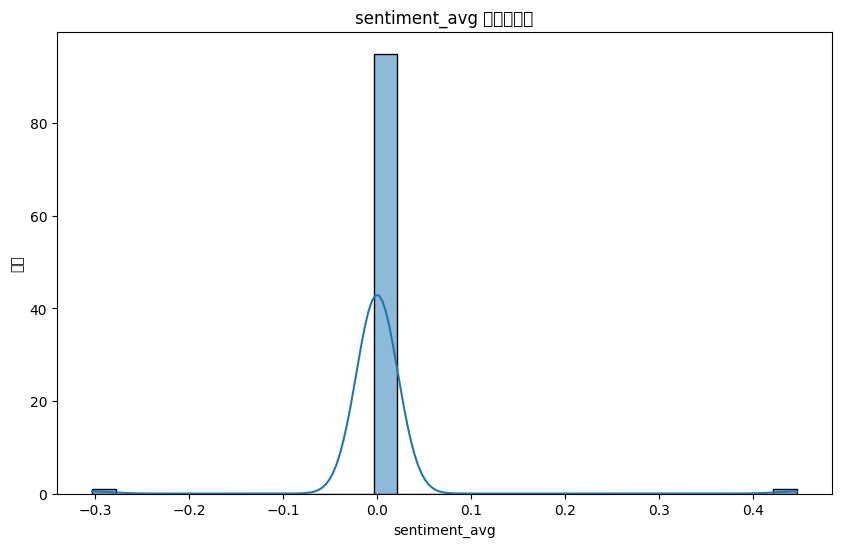

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))  # 調整圖表大小
sns.histplot(result_df['sentiment_avg'], bins=30, kde=True)  # bins 控制直方圖的區間數量，kde 顯示核密度估計
plt.title('sentiment_avg 的分佈情形')
plt.xlabel('sentiment_avg')
plt.ylabel('數量')
plt.show()